# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163

1. Discrete Fourier Transform (DFT): Find an image from the Internet and perform the following steps:

  - Convert the image to grayscale.
  - Apply the DFT and display the frequency-domain image.
  - Write a function to apply a random mask onto the frequency-domain plot. Then:
    - Create a mask to remove high-frequency components and display the resulting texture image.
    - Create a mask to remove low-frequency components and display the resulting edge image.
    - Create and apply the following type of mask to modify the frequency domain, then output the reconstructed image:

      - Create a circular mask with a specified radius r, apply it to the frequency domain as described above, and display the resulting image.

  - Combine the frequency-filtered image with the original image to observe and discuss the results.

2. Discrete Cosine Transform (DCT): Find an image from the Internet and perform the following steps:
  - Convert the image to grayscale.
  - Apply the DCT and display the transformed (frequency-domain) image.
  - Experiment with both cv2.dct() in OpenCV and scipy.fftpack.dct() in SciPy. Compare and discuss any differences between the two implementations.

3. Apply Thresholding
  - Set a threshold to retain approximately 5% of the DCT and DFT coefficients. Then reconstruct and display the compressed image results.
  - Retain only a portion of the DCT coefficients (e.g., 10–20%) and analyze how the reconstructed image quality changes.
  - Conduct an experiment by keeping only the low-frequency coefficients (top-left corner of the DCT matrix). Compare this result with the case where coefficients are kept randomly — how do they differ?
  - Load an RGB image from the Internet and analyze how DCT and DFT behave differently across color channels:
    - Convert the image into different color spaces, such as HSV (Hue, Saturation, Value).
    - Separate the RGB and HSV images into their three individual channels (R, G, B and H, S, V).
      - Apply DCT or DFT to each channel separately.
      - Display the DCT results for each channel and their corresponding inverse-transformed images (IDCT/IDFT).
      - Which channel has the strongest concentration of low-frequency energy?
      - When retaining only 10% of DCT coefficients, which channel’s reconstructed image shows the most visible quality degradation?


4. Report
  - Display the original image alongside all processed images.
  - Write a short commentary comparing the visual differences between methods and describing your observations for each transformation.

----------------------------------------------------------
5. Bonus:
Create a custom frequency-domain mask as described above, apply it to modify the frequency content, and output the reconstructed image.

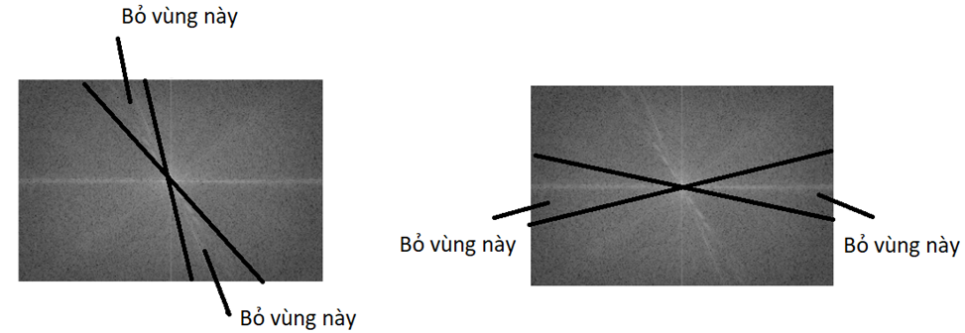

Import Libs

In [2]:
import numpy as np
import cv2
import os
import gdown
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec

from cv2 import imwrite, imread
from skimage import data, exposure, img_as_float, img_as_ubyte
from skimage import exposure
from skimage import io
from skimage.exposure import match_histograms
from scipy import ndimage
from skimage import feature
from pylab import imread
from skimage.color import rgb2gray

In [3]:
def Image3Dto2D(image):
    """
    Convert a 3D image (color) to a 2D image (grayscale).

    Parameters:
        image (ndarray): Input image, which can be 2D (grayscale) or 3D (color).

    Returns:
        image_2D (ndarray): Grayscale image as a 2D array.
    """
    # Check if the image has at least 3 dimensions (color image)
    if len(image.shape) >= 3:
        # Convert the 3D color image to grayscale using OpenCV's cvtColor function
        image_2D = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    else:
        # If the image is already 2D (grayscale), create a copy of it
        image_2D = image.copy()

    return image_2D


## 1. Discrete Fourier Transform (DFT): Find an image from the Internet and perform the following steps:

  - Convert the image to grayscale.
  - Apply the DFT and display the frequency-domain image.
  - Write a function to apply a random mask onto the frequency-domain plot. Then:
    - Create a mask to remove high-frequency components and display the resulting texture image.
    - Create a mask to remove low-frequency components and display the resulting edge image.
    - Create and apply the following type of mask to modify the frequency domain, then output the reconstructed image:

      - Create a circular mask with a specified radius r, apply it to the frequency domain as described above, and display the resulting image.

  - Combine the frequency-filtered image with the original image to observe and discuss the results.

Getting Image

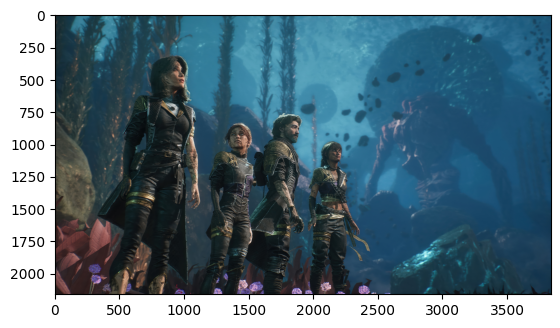

In [4]:
newImg_BGR = cv2.imread('clairobscur.jpg')  
newImg_RGB = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2RGB)


plt.imshow(newImg_RGB)
# plt.imshow(newImg2_RGB)


Convert the image to grayscale.

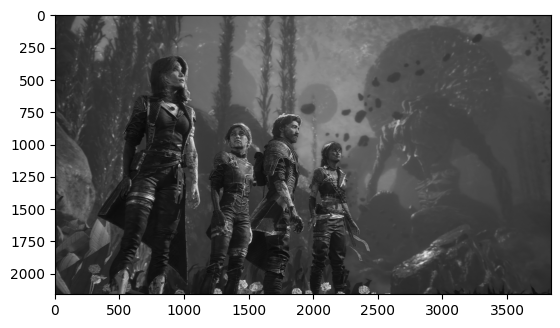

In [5]:
newImg_Gray = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2GRAY)
plt.imshow(newImg_Gray, cmap='gray')

Apply the DFT and display the frequency-domain image.

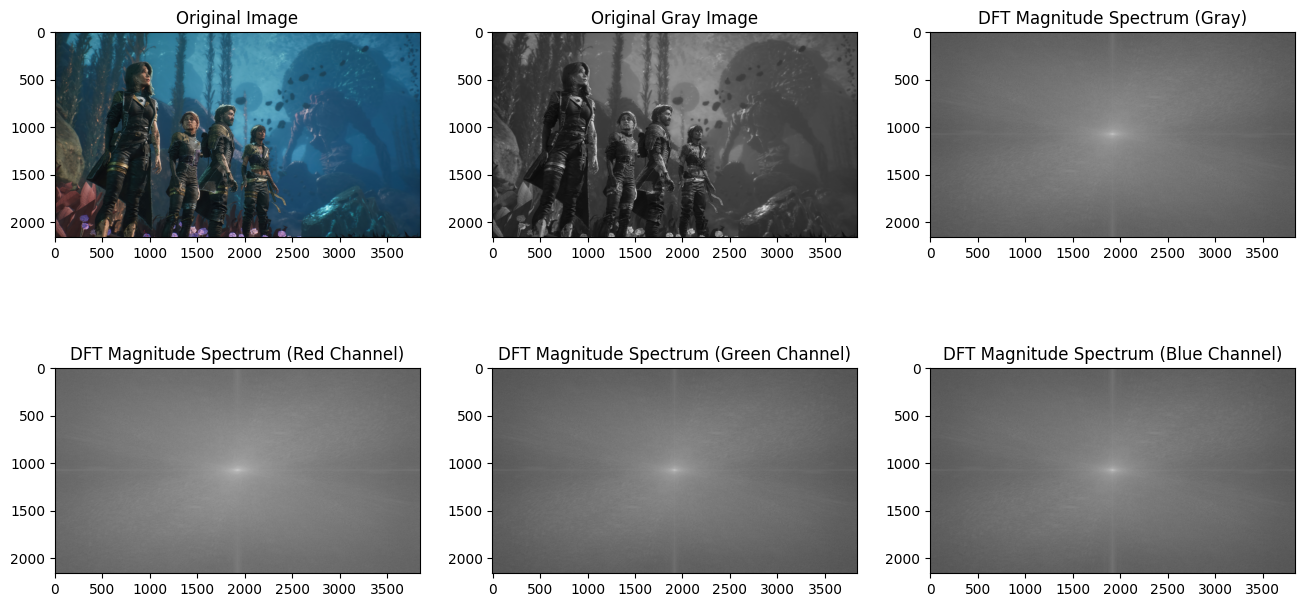

In [6]:
def DFT_Transformation(image):
    """
    Perform Discrete Fourier Transform (DFT) on an image and compute its magnitude spectrum.

    Parameters:
        image (ndarray): Input image, can be 2D (grayscale) or 3D (color).

    Returns:
        magnitude_spectrum (ndarray): The magnitude spectrum of the transformed image.
        dft_shift (ndarray): The shifted DFT result (frequency domain representation).
    """
    # Convert the image to 2D grayscale if it is a color image
    img = Image3Dto2D(image)

    # Convert the image to float32 format (required for DFT)
    img_float32 = np.float32(img)

    # Apply Discrete Fourier Transform (DFT) to the image
    dft = cv2.dft(img_float32, flags=cv2.DFT_COMPLEX_OUTPUT)

    # Shift the zero-frequency component to the center of the frequency domain
    dft_shift = np.fft.fftshift(dft)

    # Compute the magnitude spectrum (log-scaled for visualization)
    magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]))

    return magnitude_spectrum, dft_shift


# Apply the DFT and display the frequency-domain image.
image_dft_frequency, dft_shift = DFT_Transformation(newImg_RGB)
image_dft_frequency1, dft_shift1 = DFT_Transformation(newImg_RGB[:, :, 0])
image_dft_frequency2, dft_shift2 = DFT_Transformation(newImg_RGB[:, :, 1])
image_dft_frequency3, dft_shift3 = DFT_Transformation(newImg_RGB[:, :, 2])

# Display the DFT results
plt.figure(figsize=(16, 8))
plt.subplot(2, 3, 1)
plt.title('Original Image')
plt.imshow(newImg_RGB)
plt.subplot(2, 3, 2)
plt.title('Original Gray Image')
plt.imshow(newImg_Gray, cmap='gray')
plt.subplot(2, 3, 3)
plt.title('DFT Magnitude Spectrum (Gray)')
plt.imshow(image_dft_frequency, cmap='gray')
plt.subplot(2, 3, 4)
plt.title('DFT Magnitude Spectrum (Red Channel)')
plt.imshow(image_dft_frequency1, cmap='gray')
plt.subplot(2, 3, 5)
plt.title('DFT Magnitude Spectrum (Green Channel)')
plt.imshow(image_dft_frequency2, cmap='gray')
plt.subplot(2, 3, 6)
plt.title('DFT Magnitude Spectrum (Blue Channel)')
plt.imshow(image_dft_frequency3, cmap='gray')
plt.show()



  - Write a function to apply a random mask onto the frequency-domain plot. Then:
    - Create a mask to remove high-frequency components and display the resulting texture image.
    - Create a mask to remove low-frequency components and display the resulting edge image.
    - Create and apply the following type of mask to modify the frequency domain, then output the reconstructed image:

      - Create a circular mask with a specified radius r, apply it to the frequency domain as described above, and display the resulting image.

In [7]:
def apply_mask(dft_shift, mask):
    # Apply the mask to the shifted DFT
    masked_dft = dft_shift * mask

    # Shift back the zero-frequency component to the original position
    f_ishift = np.fft.ifftshift(masked_dft)

    # Perform Inverse Discrete Fourier Transform (IDFT)
    img_inverse = cv2.idft(f_ishift)

    # Compute the magnitude of the reconstructed image
    applied_image = cv2.magnitude(img_inverse[:, :, 0], img_inverse[:, :, 1])

    return applied_image


Create a mask to remove high-frequency components and display the resulting texture image.

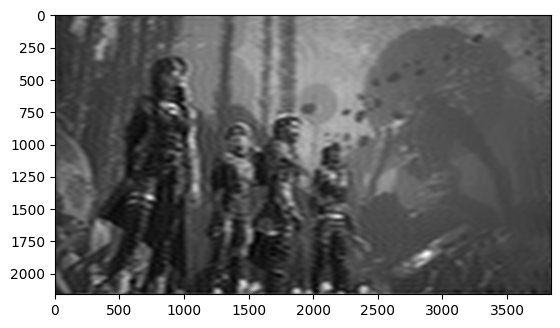

In [8]:
rows, cols = newImg_Gray.shape
crow, ccol = rows // 2 , cols // 2 
mask = np.zeros((rows, cols, 2), np.uint8)
size = 50
mask[crow-size:crow+size, ccol-size:ccol+size] = 1

texture_image = apply_mask(dft_shift, mask)
plt.imshow(texture_image,  plt.cm.gray)

Create a mask to remove low-frequency components and display the resulting edge image.

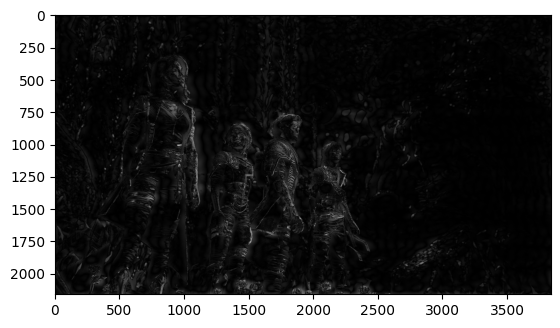

In [9]:
rows, cols = newImg_Gray.shape
crow, ccol = rows // 2 , cols // 2 
mask = np.zeros((rows, cols, 2), np.uint8)
size = 25
mask[crow-size:crow+size, ccol-size:ccol+size] = 1
mask = 1 - mask

edge_image = apply_mask(dft_shift, mask)
plt.imshow(edge_image,  plt.cm.gray)

Create a circular mask with a specified radius r, apply it to the frequency domain as described above, and display the resulting image.

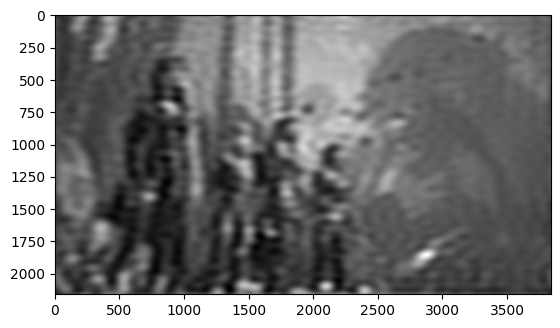

In [10]:
rows, cols = newImg_Gray.shape
crow, ccol = rows // 2 , cols // 2     # center

mask = np.zeros((rows, cols, 2), np.uint8)
r = 30  # radius
cv2.circle(mask, (ccol, crow), r, (1, 1, 1), -1)
circular_texture_image = apply_mask(dft_shift, mask)
plt.imshow(circular_texture_image, plt.cm.gray)



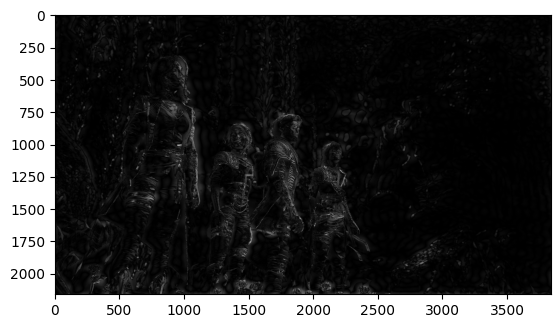

In [11]:
rows, cols = newImg_Gray.shape
crow, ccol = rows // 2 , cols // 2     # center

mask = np.ones((rows, cols, 2), np.uint8)
r = 30# radius
cv2.circle(mask, (ccol, crow), r, (0, 0, 0), -1)
edge_image = apply_mask(dft_shift, mask)
plt.imshow(edge_image, plt.cm.gray)


Combine the frequency-filtered image with the original image to observe and discuss the results.

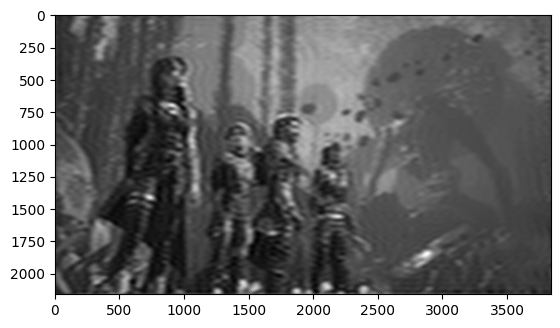

In [12]:
# - Combine the frequency-filtered image with the original image to observe and discuss the results.
img_gray = newImg_Gray.astype(np.float32) / 255.0
enhanced_freq = texture_image.astype(np.float32) / 255.0


alpha = 0.7
beta = 0.5


combined_image = cv2.addWeighted(img_gray, alpha, enhanced_freq, beta, 0)
plt.imshow(combined_image, cmap='gray')


## 2. Discrete Cosine Transform (DCT): Find an image from the Internet and perform the following steps:
  - Convert the image to grayscale.
  - Apply the DCT and display the transformed (frequency-domain) image.
  - Experiment with both cv2.dct() in OpenCV and scipy.fftpack.dct() in SciPy. Compare and discuss any differences between the two implementations.

In [13]:
def dct2(a):
    import scipy
    return scipy.fftpack.dct( scipy.fftpack.dct( a, axis=0, norm='ortho' ), axis=1, norm='ortho' )

def idct2(a):
    import scipy
    return scipy.fftpack.idct( scipy.fftpack.idct( a, axis=0 , norm='ortho'), axis=1 , norm='ortho')

Convert the image to grayscale.

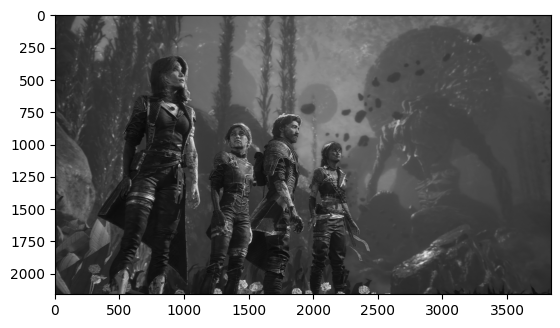

In [14]:
newImg_Gray = cv2.cvtColor(newImg_BGR, cv2.COLOR_BGR2GRAY)
plt.imshow(newImg_Gray, cmap='gray')

Apply the DCT and display the transformed (frequency-domain) image.

Text(0.5, 1.0, 'Reconstructed Image from DCT')

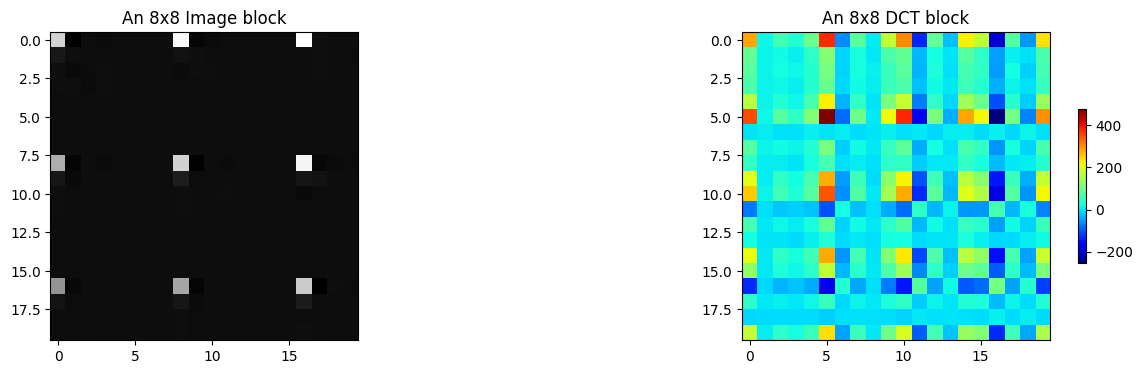

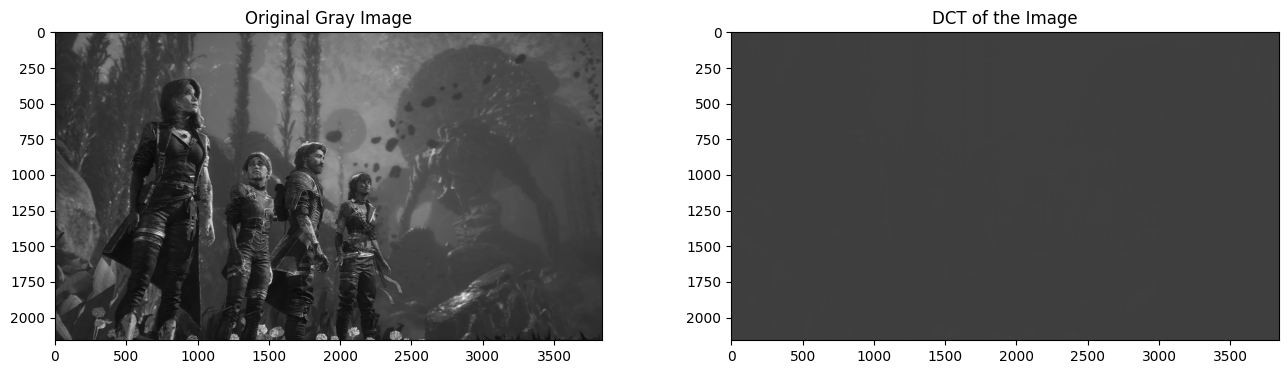

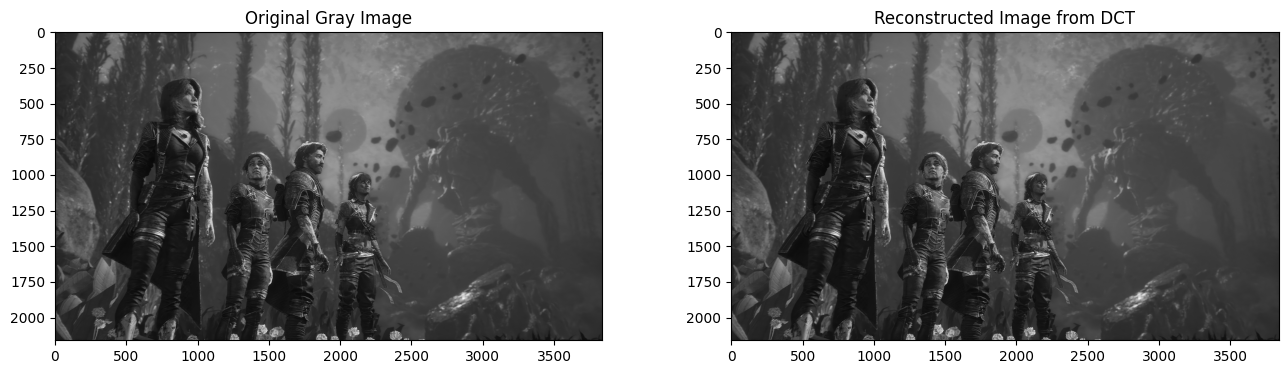

In [ ]:
# Apply the DCT and display the transformed (frequency-domain) image. 
def apply_DCT(image, n = 8, pos = 128, offset=20):
    gray_image = Image3Dto2D(newImg_RGB)
    imsize = image.shape
    dct = np.zeros(imsize)
    for i in np.r_[:imsize[0]:n]:
        for j in np.r_[:imsize[1]:n]:
            dct[i:(i+n),j:(j+n)] = dct2(gray_image[i:(i+n),j:(j+n)])
            
    image_block = dct[pos:pos+offset,pos:pos+offset] # +20 vì 
    dct_block = dct2(image_block)
    return dct , image_block, dct_block

dct, SampleBlock, SampleDCT = apply_DCT(newImg_Gray, n=8, pos=128, offset=20)
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.imshow(SampleBlock,cmap='gray')
plt.title( "An 8x8 Image block")

# Display the dct of that block
plt.subplot(1,2,2)
plt.imshow(SampleDCT,cmap=cm.jet,interpolation='nearest')
plt.colorbar(shrink=0.5)
plt.title( "An 8x8 DCT block")

# show images
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.imshow(newImg_Gray, plt.cm.gray)
plt.title('Original Gray Image')
plt.subplot(1,2,2)
plt.imshow(dct, plt.cm.gray)
plt.title('DCT of the Image')
# Inverse DCT
def apply_IDCT(dct, n = 8):
    imsize = dct.shape
    idct = np.zeros(imsize)
    for i in np.r_[:imsize[0]:n]:
        for j in np.r_[:imsize[1]:n]:
            idct[i:(i+n),j:(j+n)] = idct2(dct[i:(i+n),j:(j+n)])
    return idct
idct = apply_IDCT(dct, n=8)
# show images
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
plt.imshow(newImg_Gray, plt.cm.gray)
plt.title('Original Gray Image')
plt.subplot(1,2,2)
plt.imshow(idct, plt.cm.gray)
plt.title('Reconstructed Image from DCT')



Experiment with both cv2.dct() in OpenCV and scipy.fftpack.dct() in SciPy. Compare and discuss any differences between the two implementations.

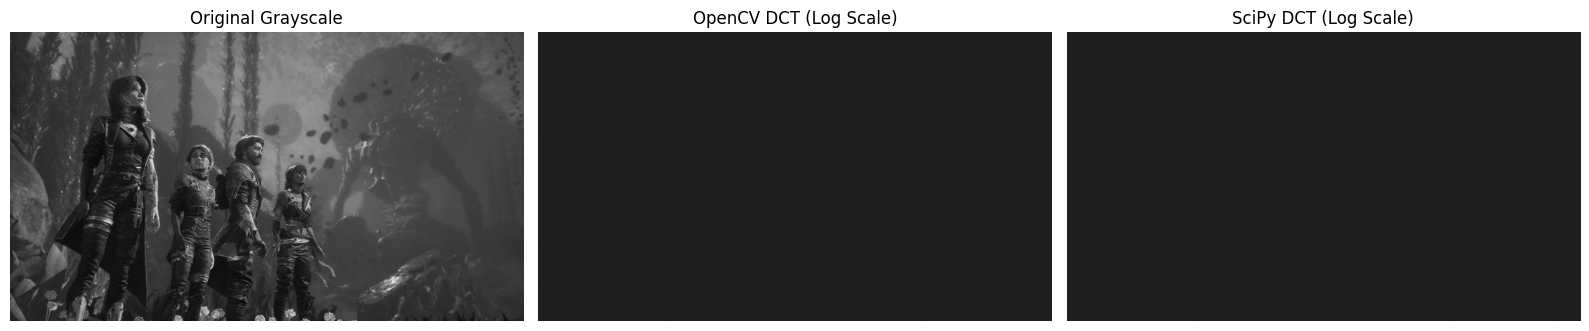

Mean difference between OpenCV and SciPy implementations: 0.000000


In [20]:


# IMPORTANT: DCT requires floating point data. 
# Pixel values are 0-255, we convert to float.
newImg_float = newImg_Gray.astype(np.float32) / 255.0

dct_opencv = cv2.dct(newImg_float)
dct_scipy = dct2(newImg_float)
# 5. Display Results
plt.figure(figsize=(16, 4))

# Original
plt.subplot(1, 3, 1)
plt.imshow(newImg_Gray, cmap='gray')
plt.title("Original Grayscale")
plt.axis('off')

# OpenCV Result
plt.subplot(1, 3, 2)
plt.imshow(dct_opencv, cmap='gray')
plt.title("OpenCV DCT (Log Scale)")
plt.axis('off')

# SciPy Result
plt.subplot(1, 3, 3)
plt.imshow(dct_scipy, cmap='gray')
plt.title("SciPy DCT (Log Scale)")
plt.axis('off')

plt.tight_layout()
plt.show()

# Verification of values
diff = np.abs(dct_opencv - dct_scipy)
print(f"Mean difference between OpenCV and SciPy implementations: {np.mean(diff):.6f}")


## 3. Apply Thresholding
  - Set a threshold to retain approximately 5% of the DCT and DFT coefficients. Then reconstruct and display the compressed image results.
  - Retain only a portion of the DCT coefficients (e.g., 10–20%) and analyze how the reconstructed image quality changes.
  - Conduct an experiment by keeping only the low-frequency coefficients (top-left corner of the DCT matrix). Compare this result with the case where coefficients are kept randomly — how do they differ?
  - Load an RGB image from the Internet and analyze how DCT and DFT behave differently across color channels:
    - Convert the image into different color spaces, such as HSV (Hue, Saturation, Value).
    - Separate the RGB and HSV images into their three individual channels (R, G, B and H, S, V).
      - Apply DCT or DFT to each channel separately.
      - Display the DCT results for each channel and their corresponding inverse-transformed images (IDCT/IDFT).
      - Which channel has the strongest concentration of low-frequency energy?
      - When retaining only 10% of DCT coefficients, which channel’s reconstructed image shows the most visible quality degradation?

## 4. Report
  - Display the original image alongside all processed images.
  - Write a short commentary comparing the visual differences between methods and describing your observations for each transformation.

### 4.1. Display the original image alongside all processed images.